# Fine-tuning Vision Transformer (ViT-Base/16) на датасете грибов


## 1. Импорты и настройки

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
from tqdm import tqdm

# Для ViT
from transformers import ViTForImageClassification, ViTConfig

/Users/mansurzainullin/MyCode/5-sem-labs-for-big-data/local_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Настройки
SEED = 42
BATCH_SIZE = 8  # Маленький batch для 8GB
MAX_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
MIN_DELTA = 0.001

# Параметры из статьи (Table 4, section B.1.1)
LEARNING_RATE = 0.003
MOMENTUM = 0.9  # Как в статье
WEIGHT_DECAY = 0.0
GRAD_CLIP = 1.0

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

Device: mps


## 2. Загрузка данных

In [3]:
data = torch.load('../data/Mushrooms_preprocessed_224.pt')
images = data['images']  # Shape: (6714, 3, 224, 224)
labels = data['labels']
class_to_idx = data['class_to_idx']

num_classes = len(class_to_idx)

print(f'Images shape: {images.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Number of classes: {num_classes}')
print(f'Classes: {class_to_idx}')

Images shape: torch.Size([6714, 3, 224, 224])
Labels shape: torch.Size([6714])
Number of classes: 9
Classes: {'Agaricus': 0, 'Amanita': 1, 'Boletus': 2, 'Cortinarius': 3, 'Entoloma': 4, 'Hygrocybe': 5, 'Lactarius': 6, 'Russula': 7, 'Suillus': 8}


## 3. Train/Test Split

In [5]:
dataset = TensorDataset(images, labels)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

g_split = torch.Generator()
g_split.manual_seed(SEED)

train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=g_split)

print(f'Train size: {train_size}')
print(f'Test size: {test_size}')

Train size: 5371
Test size: 1343


## 4. On-the-fly Augmentation

Используем аугментации из preprocess_dataset.ipynb

In [9]:
# Аугментация для train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1)
])

test_transform = None

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset_aug = TransformedDataset(train_dataset, train_transform)
test_dataset_aug = TransformedDataset(test_dataset, test_transform)

g_loader = torch.Generator()
g_loader.manual_seed(SEED)

train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, generator=g_loader)
test_loader = DataLoader(test_dataset_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Train batches: 672
Test batches: 168


## 5. Загрузка ViT-Base/16

Используем предобученную модель google/vit-base-patch16-224

In [6]:
model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    num_labels=num_classes,
    ignore_mismatched_sizes=True  # Заменяет classification head
)

model = model.to(device)

print(f'Model loaded: ViT-Base/16')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([9]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([9, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: ViT-Base/16
Total parameters: 85,805,577


## 6. Optimizer и Scheduler

Из статьи:
- SGD с momentum 0.9
- Cosine learning rate decay
- No weight decay
- Gradient clipping

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)

# Cosine annealing scheduler (как в статье)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=MAX_EPOCHS)

## 7. Early Stopping

Используем паттерн из final_ensemble.ipynb

In [8]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model.state_dict())
            self.counter = 0

early_stopping = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA)
print(f'Ранняя остановка: patience={PATIENCE}, min_delta={MIN_DELTA}')

Ранняя остановка: patience=10, min_delta=0.001


## 8. Training Loop

In [9]:
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(MAX_EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images_batch, labels_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{MAX_EPOCHS} [Train]'):
        images_batch = images_batch.to(device)
        labels_batch = labels_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images_batch)
        loss = criterion(outputs.logits, labels_batch)
        
        loss.backward()
        
        # Gradient clipping (как в статье)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.logits.max(1)
        total += labels_batch.size(0)
        correct += predicted.eq(labels_batch).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for images_batch, labels_batch in tqdm(test_loader, desc=f'Epoch {epoch+1}/{MAX_EPOCHS} [Test]'):
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            outputs = model(images_batch)
            loss = criterion(outputs.logits, labels_batch)
            
            test_running_loss += loss.item()
            _, predicted = outputs.logits.max(1)
            test_total += labels_batch.size(0)
            test_correct += predicted.eq(labels_batch).sum().item()
    
    test_loss = test_running_loss / len(test_loader)
    test_acc = 100. * test_correct / test_total
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step()
    
    early_stopping(test_loss, model)
    
    if (epoch % 10 == 0):
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
        }, f'../data/vit/vit_epoch_{epoch+1}.pth')
    
    print(f'Epoch [{epoch+1}/{MAX_EPOCHS}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%')
    print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
    print()
    
    if early_stopping.early_stop:
        print(f'Early stopping at epoch {epoch+1}')
        model.load_state_dict(early_stopping.best_model)
        break
    
    # Очистка памяти
    if device.type == 'mps':
        torch.mps.empty_cache()


Epoch 1/50 [Train]:   0%|          | 0/672 [00:00<?, ?it/s]


Epoch 1/50 [Train]:   0%|          | 1/672 [00:01<18:12,  1.63s/it]


Epoch 1/50 [Train]:   0%|          | 2/672 [00:02<13:20,  1.19s/it]


Epoch 1/50 [Train]:   0%|          | 3/672 [00:03<11:43,  1.05s/it]


Epoch 1/50 [Train]:   1%|          | 4/672 [00:04<10:57,  1.02it/s]

...


Epoch 19/50 [Test]:  99%|█████████▉| 166/168 [00:54<00:00,  3.06it/s]


Epoch 19/50 [Test]:  99%|█████████▉| 167/168 [00:54<00:00,  3.05it/s]


Epoch 19/50 [Test]: 100%|██████████| 168/168 [00:55<00:00,  3.13it/s]


Epoch 19/50 [Test]: 100%|██████████| 168/168 [00:55<00:00,  3.05it/s]

Epoch [19/50]
  Train Loss: 0.1086, Train Acc: 96.22%
  Test Loss: 0.4163, Test Acc: 88.24%
  LR: 0.002052

Early stopping at epoch 19


## 9. Сохранение финальной модели

In [10]:
# Сохранение лучшей модели
torch.save({
    'model_state_dict': model.state_dict(),
    'class_to_idx': class_to_idx,
    'test_acc': max(test_accs),
    'config': {
        'model_name': 'google/vit-base-patch16-224',
        'num_classes': num_classes,
        'batch_size': BATCH_SIZE,
        'learning_rate': LEARNING_RATE,
        'momentum': MOMENTUM,
    }
}, '../data/vit_finetuned_final.pth')

print(f'Final model saved to ../data/vit_finetuned_final.pth')
print(f'Best test accuracy: {max(test_accs):.2f}%')

Final model saved to ../data/vit_finetuned_final.pth
Best test accuracy: 88.24%


## 10. Визуализация результатов

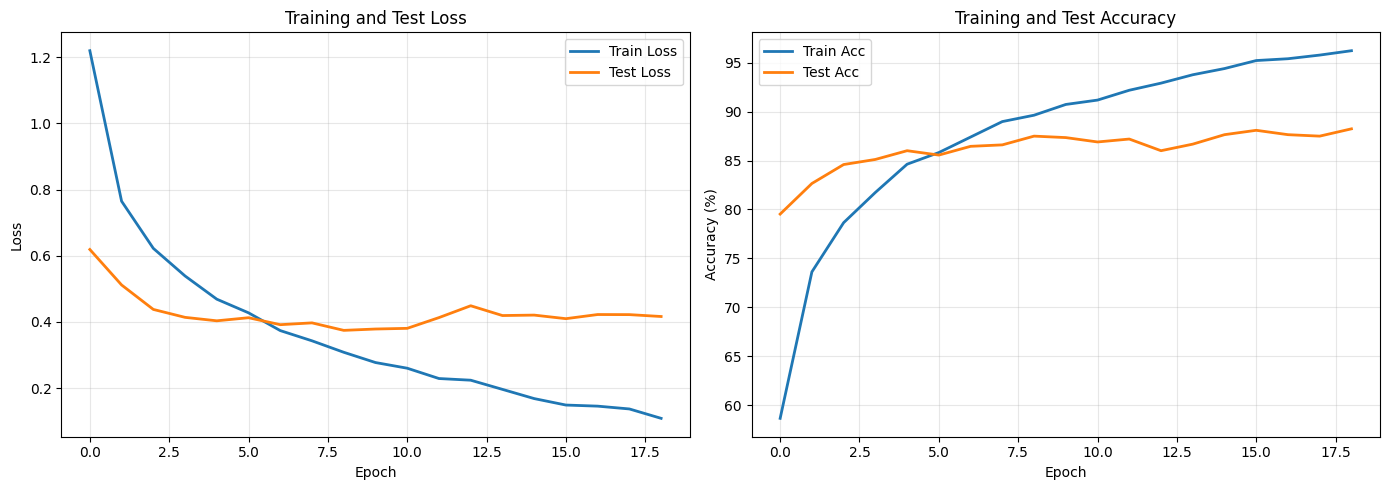

Training curves saved to ../data/vit_training_curves.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(train_accs, label='Train Acc', linewidth=2)
axes[1].plot(test_accs, label='Test Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vit_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Training curves saved to ../data/vit_training_curves.png')

In [6]:
# Данные из логов обучения ViT (параграф 8)
vit_test_losses = [0.6189, 0.5117, 0.4377, 0.4138, 0.4033, 0.4127, 0.3916, 0.3971, 0.3745, 0.3785,
                   0.3806, 0.4130, 0.4488, 0.4192, 0.4206, 0.4098, 0.4223, 0.4220, 0.4163]
vit_test_accs = [79.52, 82.65, 84.59, 85.11, 86.00, 85.55, 86.45, 86.60, 87.49, 87.34,
                 86.90, 87.19, 86.00, 86.67, 87.64, 88.09, 87.64, 87.49, 88.24]

print(f'ViT epochs: {len(vit_test_losses)}')
print(f'ViT best test accuracy: {max(vit_test_accs):.2f}%')

ViT epochs: 19
ViT best test accuracy: 88.24%


In [7]:
# Архитектура CNN модели из final_ensemble
class ScalableCombinedCNN(nn.Module):
    def __init__(self, channels, num_classes=9, dropout_conv=0.3, dropout_fc=0.5):
        super(ScalableCombinedCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, channels['conv1'], kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels['conv1'])
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(dropout_conv)

        self.conv2 = nn.Conv2d(channels['conv1'], channels['conv2'], kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels['conv2'])
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(dropout_conv)

        self.conv3 = nn.Conv2d(channels['conv2'], channels['conv3'], kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(channels['conv3'])
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout(dropout_conv + 0.1)

        self.conv4 = nn.Conv2d(channels['conv3'], channels['conv4'], kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(channels['conv4'])
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout(dropout_conv + 0.1)

        self.conv5 = nn.Conv2d(channels['conv4'], channels['conv5'], kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(channels['conv5'])
        self.pool5 = nn.MaxPool2d(2, 2)
        self.dropout5 = nn.Dropout(dropout_conv + 0.2)

        flatten_size = channels['conv5'] * 4 * 4
        self.fc1 = nn.Linear(flatten_size, channels['fc1'])
        self.bn_fc1 = nn.BatchNorm1d(channels['fc1'])
        self.dropout_fc1 = nn.Dropout(dropout_fc + 0.1)

        self.fc2 = nn.Linear(channels['fc1'], channels['fc2'])
        self.bn_fc2 = nn.BatchNorm1d(channels['fc2'])
        self.dropout_fc2 = nn.Dropout(dropout_fc)

        self.fc3 = nn.Linear(channels['fc2'], num_classes)

    def forward(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.dropout1(x)

        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.dropout2(x)

        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        x = self.dropout3(x)

        x = self.pool4(torch.relu(self.bn4(self.conv4(x))))
        x = self.dropout4(x)

        x = self.pool5(torch.relu(self.bn5(self.conv5(x))))
        x = self.dropout5(x)

        x = x.view(x.size(0), -1)

        x = torch.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout_fc1(x)

        x = torch.relu(self.bn_fc2(self.fc2(x)))
        x = self.dropout_fc2(x)

        x = self.fc3(x)
        return x

checkpoint_42 = torch.load('../data/model_seed42.pth', map_location=device, weights_only=False)
model_seed42 = ScalableCombinedCNN(
    channels=checkpoint_42['channels'],
    dropout_conv=checkpoint_42['dropout_conv'],
    dropout_fc=checkpoint_42['dropout_fc']
).to(device)
model_seed42.load_state_dict(checkpoint_42['state_dict'])
model_seed42.eval()

ensemble_checkpoint = torch.load('../data/ensemble_models.pth', map_location=device, weights_only=False)
ensemble_seeds = [42, 100, 200]
ensemble_models = []

for seed in ensemble_seeds:
    model_ens = ScalableCombinedCNN(
        channels=ensemble_checkpoint['channels'],
        dropout_conv=ensemble_checkpoint['dropout_conv'],
        dropout_fc=ensemble_checkpoint['dropout_fc']
    ).to(device)
    model_ens.load_state_dict(ensemble_checkpoint[f'seed_{seed}'])
    model_ens.eval()
    ensemble_models.append(model_ens)

print(f'Загружена модель CNN seed42')
print(f'Загружен ансамбль из {len(ensemble_models)} CNN моделей: seeds {ensemble_seeds}')

Загружена модель CNN seed42
Загружен ансамбль из 3 CNN моделей: seeds [42, 100, 200]


In [10]:
# Вычисление метрик CNN моделей на том же test_dataset
resize_transform = transforms.Resize((128, 128))
criterion = nn.CrossEntropyLoss()

def evaluate_cnn_model(model, test_loader):
    """Вычисление loss и accuracy для CNN модели"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images_batch, labels_batch in test_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            # Resize для CNN (224 -> 128)
            images_batch = resize_transform(images_batch)

            outputs = model(images_batch)
            loss = criterion(outputs, labels_batch)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels_batch.size(0)
            correct += predicted.eq(labels_batch).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

def evaluate_ensemble(models, test_loader):
    """Вычисление loss и accuracy для ансамбля моделей"""
    for model in models:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images_batch, labels_batch in test_loader:
            images_batch = images_batch.to(device)
            labels_batch = labels_batch.to(device)

            # Resize для CNN (224 -> 128)
            images_batch = resize_transform(images_batch)

            # Усреднение вероятностей от всех моделей
            probs = torch.stack([
                torch.softmax(model(images_batch), dim=1)
                for model in models
            ]).mean(dim=0)

            # Loss вычисляем от усредненных вероятностей
            loss = criterion(torch.log(probs + 1e-10), labels_batch)

            total_loss += loss.item()
            predictions = probs.argmax(dim=1)
            total += labels_batch.size(0)
            correct += predictions.eq(labels_batch).sum().item()

    avg_loss = total_loss / len(test_loader)
    accuracy = 100. * correct / total
    return avg_loss, accuracy

# Вычисление метрик
cnn_seed42_loss, cnn_seed42_acc = evaluate_cnn_model(model_seed42, test_loader)
ensemble_loss, ensemble_acc = evaluate_ensemble(ensemble_models, test_loader)

print(f'\nРезультаты на test_dataset (n={test_size}):')
print(f'CNN seed42:    Loss={cnn_seed42_loss:.4f}, Accuracy={cnn_seed42_acc:.2f}%')
print(f'CNN ensemble:  Loss={ensemble_loss:.4f}, Accuracy={ensemble_acc:.2f}%')
print(f'ViT (epoch 19): Loss={vit_test_losses[-1]:.4f}, Accuracy={vit_test_accs[-1]:.2f}%')


Результаты на test_dataset (n=1343):
CNN seed42:    Loss=0.3374, Accuracy=88.01%
CNN ensemble:  Loss=0.2727, Accuracy=91.21%
ViT (epoch 19): Loss=0.4163, Accuracy=88.24%


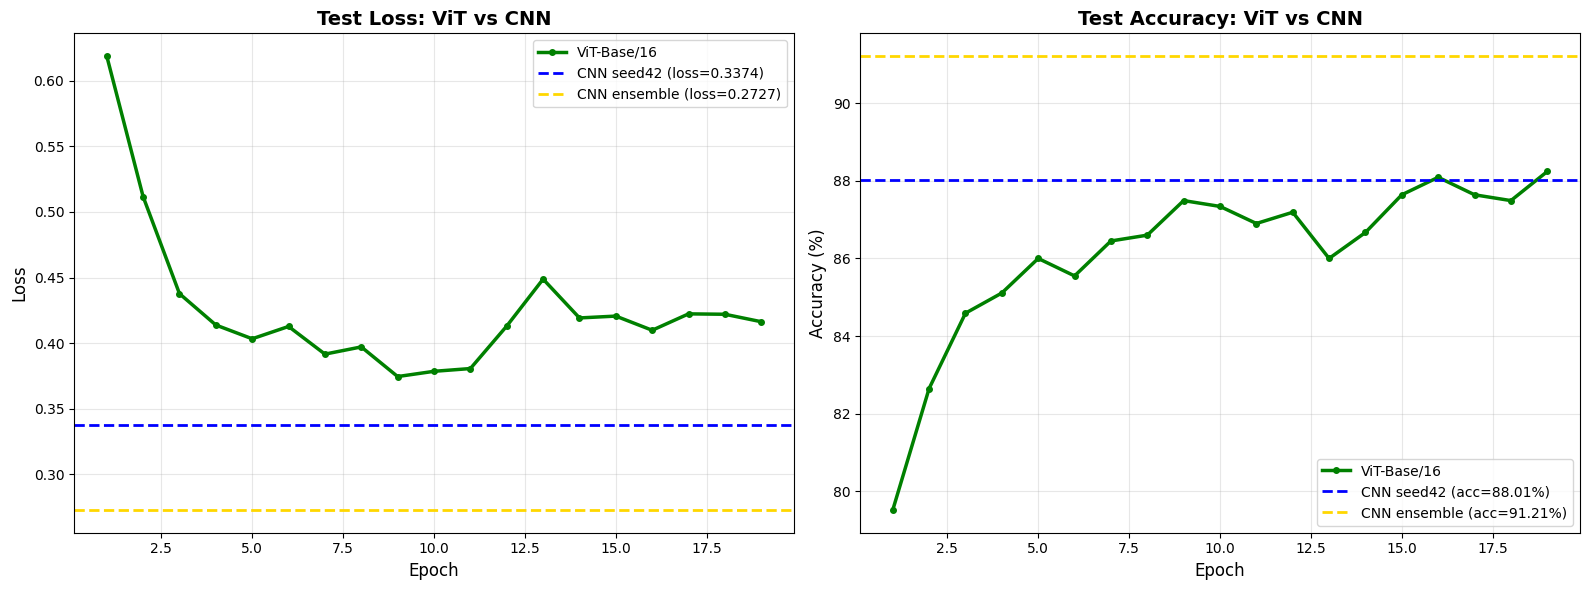


Графики сравнения сохранены в ../data/vit_vs_cnn_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

epochs = range(1, len(vit_test_losses) + 1)

# Test Loss
axes[0].plot(epochs, vit_test_losses, label='ViT-Base/16', linewidth=2.5, color='green', marker='o', markersize=4)
axes[0].axhline(y=cnn_seed42_loss, color='blue', linestyle='--', linewidth=2, label=f'CNN seed42 (loss={cnn_seed42_loss:.4f})')
axes[0].axhline(y=ensemble_loss, color='gold', linestyle='--', linewidth=2, label=f'CNN ensemble (loss={ensemble_loss:.4f})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Test Loss: ViT vs CNN', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Test Accuracy
axes[1].plot(epochs, vit_test_accs, label='ViT-Base/16', linewidth=2.5, color='green', marker='o', markersize=4)
axes[1].axhline(y=cnn_seed42_acc, color='blue', linestyle='--', linewidth=2, label=f'CNN seed42 (acc={cnn_seed42_acc:.2f}%)')
axes[1].axhline(y=ensemble_acc, color='gold', linestyle='--', linewidth=2, label=f'CNN ensemble (acc={ensemble_acc:.2f}%)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Test Accuracy: ViT vs CNN', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vit_vs_cnn_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nГрафики сравнения сохранены в ../data/vit_vs_cnn_comparison.png')